# Baseline Model Development and Comparison

## Objective

This notebook trains and compares five classifiers to predict obesity-risk categories: Dummy Classifier, Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

All models use the same training and validation data for a fair comparison. The test data is kept separate for final evaluation.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Locate the project root
PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "src" / "preprocessing.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root not found.")

# Allow notebooks to import project modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    PREDICTIVE_FEATURES,
    build_preprocessor,
)

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "obesity.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset available:", DATA_PATH.exists())
print("Predictive features:", len(PREDICTIVE_FEATURES))
print("Preprocessor:", type(build_preprocessor()).__name__)

Project root: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM
Dataset available: True
Predictive features: 16
Preprocessor: ColumnTransformer


## Dataset Preparation

Load the dataset and separate the 16 predictive features from the target variable, `NObeyesdad`, which contains seven obesity-risk categories.

The `id` column is excluded because it identifies records rather than describing obesity risk. The code also checks that the required columns and dataset dimensions are correct.

In [2]:
# Load the dataset
DATA_PATH = "../data/raw/obesity.csv"
df = pd.read_csv(DATA_PATH)

TARGET_COLUMN = "NObeyesdad"
RANDOM_STATE = 42

# Confirm the required columns exist
missing_features = set(PREDICTIVE_FEATURES) - set(df.columns)

assert not missing_features, f"Missing features: {missing_features}"
assert TARGET_COLUMN in df.columns, "Target column is missing."

# Separate predictors and target
X = df[PREDICTIVE_FEATURES].copy()
y = df[TARGET_COLUMN].copy()

# Verify the dataset structure
assert X.shape == (20758, 16)
assert y.nunique() == 7
assert list(X.columns) == PREDICTIVE_FEATURES

print("Dataset shape:", df.shape)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Number of target classes:", y.nunique())
print("Identifier excluded:", "id" not in X.columns)

Dataset shape: (20758, 18)
Feature shape: (20758, 16)
Target shape: (20758,)
Number of target classes: 7
Identifier excluded: True


## Training, Validation and Test Split

Split the dataset into 70% training, 15% validation, and 15% test data.

Stratification maintains similar class proportions in each subset. Training data is used to fit models, validation data is used to compare them, and test data is kept separate for final evaluation.

Random state 42 makes the split reproducible.

In [3]:
# First split: 70% training and 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Second split: divide the temporary data equally
# into validation and test datasets
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

# Summarize the split
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Records": [
        len(X_train),
        len(X_validation),
        len(X_test),
    ],
    "Percentage": [
        len(X_train) / len(X) * 100,
        len(X_validation) / len(X) * 100,
        len(X_test) / len(X) * 100,
    ],
})

split_summary["Percentage"] = split_summary["Percentage"].round(2)

# Verify sizes and ensure no records overlap
assert X_train.shape == (14530, 16)
assert X_validation.shape == (3114, 16)
assert X_test.shape == (3114, 16)

assert set(X_train.index).isdisjoint(X_validation.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_validation.index).isdisjoint(X_test.index)

assert len(X_train) + len(X_validation) + len(X_test) == len(X)

print("Dataset splitting completed successfully")
display(split_summary)

Dataset splitting completed successfully


,Dataset,Records,Percentage
0,Training,14530,70.0
1,Validation,3114,15.0
2,Test,3114,15.0


## Model Evaluation Metrics

Define one evaluation function to measure every classifier consistently using four metrics:

- **Accuracy:** Overall proportion of correct predictions.
- **Balanced Accuracy:** Average recall across all classes.
- **Macro F1:** Average F1-score, giving each class equal importance.
- **Weighted F1:** Average F1-score adjusted for class sizes.

Macro F1 is the main metric for comparing models.

In [4]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

CLASS_ORDER = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

def calculate_classification_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }

print("Evaluation metrics configured successfully")
print("Number of target classes:", len(CLASS_ORDER))

Evaluation metrics configured successfully
Number of target classes: 7


## Dummy Classifier

Train a simple reference model that always predicts the most common obesity-risk category in the training data.

Its validation results provide a starting point for checking whether the machine learning models perform better than a basic majority-class prediction.

In [5]:
from sklearn.dummy import DummyClassifier

# Identify the most frequent class in the training dataset
most_frequent_class = y_train.value_counts().idxmax()

print("Most frequent training class:", most_frequent_class)

# Create and train the Dummy Classifier
dummy_classifier = DummyClassifier(strategy="most_frequent")

dummy_classifier.fit(X_train, y_train)

# Predict the validation dataset
dummy_validation_predictions = dummy_classifier.predict(X_validation)

# Evaluate the predictions
dummy_result = calculate_classification_metrics(
    "Dummy Classifier",
    y_validation,
    dummy_validation_predictions,
)

# Initialize the results list for all five classifiers
model_results = [dummy_result]

# Display results
display(pd.DataFrame(model_results).round(4).style.hide(axis="index"))

print(
    "\nPredicted classes:",
    np.unique(dummy_validation_predictions),
)

print(
    "Number of validation predictions:",
    len(dummy_validation_predictions),
)

# Verify expected Dummy Classifier behaviour
assert len(dummy_validation_predictions) == len(y_validation)
assert len(np.unique(dummy_validation_predictions)) == 1
assert dummy_validation_predictions[0] == most_frequent_class

Most frequent training class: Obesity_Type_III


Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
Dummy Classifier,0.194900,0.142900,0.046600,0.063600



Predicted classes: ['Obesity_Type_III']
Number of validation predictions: 3114


## Training the Baseline Models

Train Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting using their baseline settings.

Each model has its own preprocessing pipeline, fitted only on training data to avoid data leakage.

Record training and validation scores to compare predictive performance and identify possible overfitting.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

# Define the four baseline classifiers
baseline_models = {
    "Logistic Regression": LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

print("Baseline algorithms configured:")
for model_name in baseline_models:
    print("-", model_name)

Baseline algorithms configured:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [7]:
# Store fitted pipelines and evaluation results
trained_models = {}
training_results = []

for model_name, classifier in baseline_models.items():

    print(f"\nTraining: {model_name}")

    # Create a complete preprocessing + classification pipeline
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("classifier", classifier),
        ]
    )

    # Train using training data only
    model_pipeline.fit(X_train, y_train)

    # Generate training and validation predictions
    train_predictions = model_pipeline.predict(X_train)
    validation_predictions = model_pipeline.predict(X_validation)

    # Evaluate training performance
    train_result = calculate_classification_metrics(
        model_name,
        y_train,
        train_predictions,
    )

    # Evaluate validation performance
    validation_result = calculate_classification_metrics(
        model_name,
        y_validation,
        validation_predictions,
    )

    # Preserve results for later comparison
    trained_models[model_name] = model_pipeline
    training_results.append(train_result)
    model_results.append(validation_result)

    # Verify the transformed feature count
    transformed_features = (
        model_pipeline.named_steps["preprocessor"]
        .get_feature_names_out()
    )

    assert len(transformed_features) == 25
    assert len(validation_predictions) == len(y_validation)

    print(
        f"Training Macro F1: "
        f"{train_result['Macro F1']:.4f}"
    )

    print(
        f"Validation Macro F1: "
        f"{validation_result['Macro F1']:.4f}"
    )

    print(
        f"Transformed features: {len(transformed_features)}"
    )

print("\nAll four baseline models trained successfully")


Training: Logistic Regression


c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Training Macro F1: 0.8443
Validation Macro F1: 0.8418
Transformed features: 25

Training: Decision Tree
Training Macro F1: 1.0000
Validation Macro F1: 0.8308
Transformed features: 25

Training: Random Forest
Training Macro F1: 1.0000
Validation Macro F1: 0.8849
Transformed features: 25

Training: Gradient Boosting
Training Macro F1: 0.9126
Validation Macro F1: 0.8930
Transformed features: 25

All four baseline models trained successfully


## Baseline Model Comparison

Compare all five classifiers using their validation scores.

Sort the models by Macro F1, followed by Balanced Accuracy and Accuracy. Calculate ranking columns to make their relative performance easier to compare.

The Dummy Classifier remains as a reference model.

In [8]:
# Create the complete baseline comparison table
baseline_comparison_df = (
    pd.DataFrame(model_results)
    .set_index("Model")
    .sort_values(
        by=[
            "Macro F1",
            "Balanced Accuracy",
            "Accuracy",
        ],
        ascending=False,
    )
)

# Add the three ranking columns
baseline_ranking_df = baseline_comparison_df.copy()

for metric in [
    "Macro F1",
    "Balanced Accuracy",
    "Accuracy",
]:
    baseline_ranking_df[f"{metric} Rank"] = (
        baseline_ranking_df[metric]
        .rank(
            ascending=False,
            method="min",
        )
        .astype(int)
    )

# Display Model in the same header row as other columns
display(
    baseline_ranking_df
    .reset_index()
    .round(4)
    .style.hide(axis="index")
)

print("Number of models compared:", len(baseline_ranking_df))

Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro F1 Rank,Balanced Accuracy Rank,Accuracy Rank
Gradient Boosting,0.903300,0.893100,0.893000,0.903000,1,1,1
Random Forest,0.895600,0.884500,0.884900,0.895300,2,2,2
Logistic Regression,0.858100,0.843200,0.841800,0.856600,3,3,3
Decision Tree,0.845200,0.831200,0.830800,0.845600,4,4,4
Dummy Classifier,0.194900,0.142900,0.046600,0.063600,5,5,5


Number of models compared: 5


## Training and Validation Performance

Compare training and validation Macro F1 scores to examine how well each model performs on unseen data.

**Macro F1 Gap = Training Macro F1 − Validation Macro F1**

A large positive gap can indicate overfitting. A smaller gap means the training and validation scores are more similar.

In [9]:
# Compare training and validation Macro F1 scores
generalisation_comparison_df = pd.DataFrame({
    "Model": [
        result["Model"]
        for result in training_results
    ],

    "Training Macro F1": [
        result["Macro F1"]
        for result in training_results
    ],
})

# Add validation Macro F1 from the baseline comparison
generalisation_comparison_df["Validation Macro F1"] = (
    generalisation_comparison_df["Model"]
    .map(baseline_comparison_df["Macro F1"])
)

# Calculate the generalisation gap
generalisation_comparison_df["Macro F1 Gap"] = (
    generalisation_comparison_df["Training Macro F1"]
    - generalisation_comparison_df["Validation Macro F1"]
)

# Sort by validation performance
generalisation_comparison_df = (
    generalisation_comparison_df
    .sort_values(
        by="Validation Macro F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    generalisation_comparison_df
    .style.format(precision=4)
    .hide(axis="index")
)

print(
    "Number of ML models analysed:",
    len(generalisation_comparison_df),
)

Model,Training Macro F1,Validation Macro F1,Macro F1 Gap
Gradient Boosting,0.9126,0.8930,0.0196
Random Forest,1.0000,0.8849,0.1151
Logistic Regression,0.8443,0.8418,0.0025
Decision Tree,1.0000,0.8308,0.1692


Number of ML models analysed: 4


## Model Candidate Selection

Exclude the Dummy Classifier and compare the four machine learning models using validation performance and generalisation.

Rank them by higher Macro F1, higher Balanced Accuracy, and then a smaller Macro F1 gap.

Select the top two models for further improvement.

In [10]:
# Exclude the Dummy Classifier and combine validation
# performance with generalisation results
candidate_selection_df = (
    baseline_comparison_df
    .drop(index="Dummy Classifier")
    .reset_index()
    .merge(
        generalisation_comparison_df[
            [
                "Model",
                "Training Macro F1",
                "Macro F1 Gap",
            ]
        ],
        on="Model",
        how="left",
    )
)

# Apply the original model-selection criteria
candidate_selection_df = (
    candidate_selection_df
    .sort_values(
        by=[
            "Macro F1",
            "Balanced Accuracy",
            "Macro F1 Gap",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

# Display all four eligible models
display(
    candidate_selection_df
    .style.format(precision=4)
    .hide(axis="index")
)

# Select the top two candidates
tuning_candidates_df = (
    candidate_selection_df
    .head(2)
    .copy()
)

print("\nSelected tuning candidates:")

for number, model_name in enumerate(
    tuning_candidates_df["Model"],
    start=1,
):
    print(f"{number}. {model_name}")

# Validate selection
assert len(candidate_selection_df) == 4
assert len(tuning_candidates_df) == 2
assert "Dummy Classifier" not in tuning_candidates_df["Model"].values

Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Training Macro F1,Macro F1 Gap
Gradient Boosting,0.9033,0.8931,0.8930,0.9030,0.9126,0.0196
Random Forest,0.8956,0.8845,0.8849,0.8953,1.0000,0.1151
Logistic Regression,0.8581,0.8432,0.8418,0.8566,0.8443,0.0025
Decision Tree,0.8452,0.8312,0.8308,0.8456,1.0000,0.1692



Selected tuning candidates:
1. Gradient Boosting
2. Random Forest


## Baseline Model Visualizations

Visualize the model results using two charts:

1. Compare the four validation metrics across all five classifiers.
2. Compare training and validation Macro F1 to identify possible overfitting.

These charts make the differences between models easier to understand.

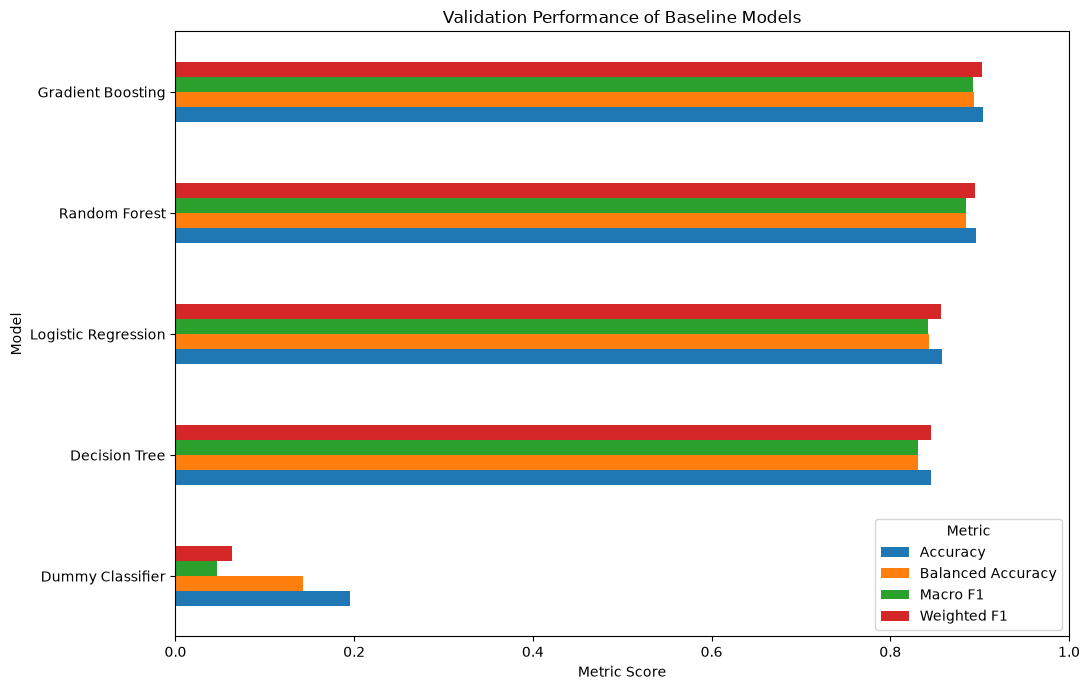

In [11]:
# Arrange the models by validation Macro F1
comparison_chart_df = (
    baseline_comparison_df[
        [
            "Accuracy",
            "Balanced Accuracy",
            "Macro F1",
            "Weighted F1",
        ]
    ]
    .sort_values(
        by="Macro F1",
        ascending=True,
    )
)

# Plot validation performance
comparison_chart_df.plot(
    kind="barh",
    figsize=(11, 7),
)

plt.title("Validation Performance of Baseline Models")
plt.xlabel("Metric Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.show()

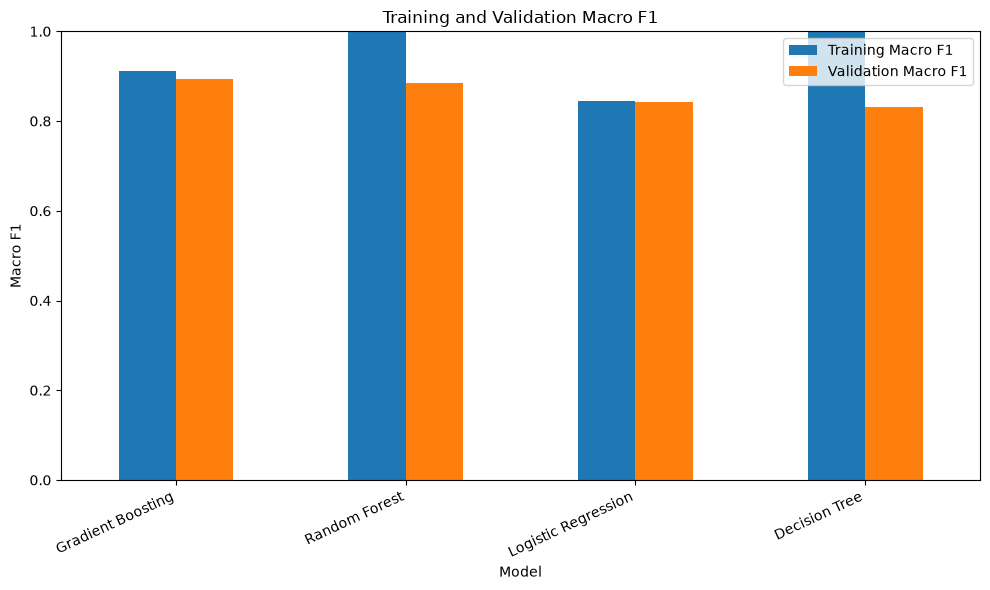

In [12]:
# Prepare the training and validation comparison
generalisation_chart_df = (
    generalisation_comparison_df
    .set_index("Model")[
        [
            "Training Macro F1",
            "Validation Macro F1",
        ]
    ]
)

# Plot the generalisation comparison
generalisation_chart_df.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Training and Validation Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Key Findings

Gradient Boosting achieved the highest validation Macro F1, followed by Random Forest.

Decision Tree showed a large training–validation gap, suggesting overfitting. Logistic Regression had a smaller gap but lower validation performance than the leading models.

Gradient Boosting and Random Forest were selected for further improvement.

## Detailed Evaluation of the Leading Baseline Model

Examine the leading model using validation predictions.

The classification report shows precision, recall, F1-score, and support for each obesity-risk category.

The confusion matrix shows correct predictions and which categories the model confuses.

Together, they reveal class-level performance that overall scores may hide.

In [13]:
# Identify the leading baseline model
leading_model_name = candidate_selection_df.iloc[0]["Model"]

leading_model = trained_models[leading_model_name]

# Generate validation predictions
leading_predictions = leading_model.predict(X_validation)

print("Leading baseline model:", leading_model_name)

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_validation,
        leading_predictions,
        labels=CLASS_ORDER,
        digits=4,
        zero_division=0,
    )
)

# Confusion matrix
confusion_values = confusion_matrix(
    y_validation,
    leading_predictions,
    labels=CLASS_ORDER,
)

confusion_df = pd.DataFrame(
    confusion_values,
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
)

confusion_df.index.name = "Actual"
confusion_df.columns.name = "Predicted"

print("\nConfusion Matrix:")

display(confusion_df)

# Verify all validation records are included
assert confusion_values.sum() == len(y_validation)

print(
    "\nValidation records evaluated:",
    confusion_values.sum(),
)

Leading baseline model: Gradient Boosting

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight     0.9253    0.9472    0.9361       379
      Normal_Weight     0.8855    0.8855    0.8855       463
 Overweight_Level_I     0.8092    0.7692    0.7887       364
Overweight_Level_II     0.8074    0.8095    0.8085       378
     Obesity_Type_I     0.8747    0.8807    0.8777       436
    Obesity_Type_II     0.9513    0.9630    0.9571       487
   Obesity_Type_III     0.9983    0.9967    0.9975       607

           accuracy                         0.9033      3114
          macro avg     0.8931    0.8931    0.8930      3114
       weighted avg     0.9027    0.9033    0.9030      3114


Confusion Matrix:


Predicted,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
Actual,,,,,,,
Insufficient_Weight,359,17,3,0,0,0,0
Normal_Weight,27,410,24,2,0,0,0
Overweight_Level_I,1,29,280,48,6,0,0
Overweight_Level_II,0,6,31,306,31,4,0
Obesity_Type_I,1,1,7,23,384,19,1
Obesity_Type_II,0,0,1,0,17,469,0
Obesity_Type_III,0,0,0,0,1,1,605



Validation records evaluated: 3114


## Saving and Verifying Results

Save the calculated results in two CSV files:

- `baseline_model_comparison.csv`: Performance and rankings of all five classifiers.
- `tuning_candidates.csv`: The two selected models, their validation scores, and generalisation gaps.

Reload both files and verify their columns, model names, row counts, and metric values to ensure the saved results are correct.

In [14]:
# Create the report directory
REPORT_DIRECTORY = PROJECT_ROOT / "reports" / "generated"
REPORT_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Define the original report filenames
BASELINE_REPORT_PATH = (
    REPORT_DIRECTORY / "baseline_model_comparison.csv"
)

CANDIDATE_REPORT_PATH = (
    REPORT_DIRECTORY / "tuning_candidates.csv"
)

# Save all five baseline model results
baseline_ranking_df.reset_index().to_csv(
    BASELINE_REPORT_PATH,
    index=False,
)

# Save the two selected tuning candidates
tuning_candidates_df.to_csv(
    CANDIDATE_REPORT_PATH,
    index=False,
)

print("Baseline comparison saved to:")
print(BASELINE_REPORT_PATH)

print("\nTuning candidates saved to:")
print(CANDIDATE_REPORT_PATH)

Baseline comparison saved to:
c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\baseline_model_comparison.csv

Tuning candidates saved to:
c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\tuning_candidates.csv


In [15]:
# Reload the saved reports
saved_baseline_df = pd.read_csv(BASELINE_REPORT_PATH)
saved_candidates_df = pd.read_csv(CANDIDATE_REPORT_PATH)

# Verify the exact report structure
expected_baseline_columns = [
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "Weighted F1",
    "Macro F1 Rank",
    "Balanced Accuracy Rank",
    "Accuracy Rank",
]

expected_candidate_columns = [
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "Weighted F1",
    "Training Macro F1",
    "Macro F1 Gap",
]

assert saved_baseline_df.columns.tolist() == expected_baseline_columns
assert saved_candidates_df.columns.tolist() == expected_candidate_columns

assert len(saved_baseline_df) == 5
assert len(saved_candidates_df) == 2

assert saved_candidates_df["Model"].tolist() == [
    "Gradient Boosting",
    "Random Forest",
]

assert "Dummy Classifier" not in saved_candidates_df["Model"].values

print("Both CSV reports verified successfully")

print("\nBaseline comparison:")
display(
    saved_baseline_df
    .style.format(precision=4)
    .hide(axis="index")
)

print("\nTuning candidates:")
display(
    saved_candidates_df
    .style.format(precision=4)
    .hide(axis="index")
)

Both CSV reports verified successfully

Baseline comparison:


Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro F1 Rank,Balanced Accuracy Rank,Accuracy Rank
Gradient Boosting,0.9033,0.8931,0.8930,0.9030,1,1,1
Random Forest,0.8956,0.8845,0.8849,0.8953,2,2,2
Logistic Regression,0.8581,0.8432,0.8418,0.8566,3,3,3
Decision Tree,0.8452,0.8312,0.8308,0.8456,4,4,4
Dummy Classifier,0.1949,0.1429,0.0466,0.0636,5,5,5



Tuning candidates:


Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Training Macro F1,Macro F1 Gap
Gradient Boosting,0.9033,0.8931,0.8930,0.9030,0.9126,0.0196
Random Forest,0.8956,0.8845,0.8849,0.8953,1.0000,0.1151


In [16]:
# Confirm that CSV export preserved the calculated metric values
pd.testing.assert_frame_equal(
    saved_baseline_df,
    baseline_ranking_df.reset_index(),
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

pd.testing.assert_frame_equal(
    saved_candidates_df,
    tuning_candidates_df,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

print("CSV values match the calculated notebook results")

CSV values match the calculated notebook results


## Conclusion

Five baseline classifiers were trained and evaluated using the same stratified training and validation datasets.

Gradient Boosting achieved the highest validation Macro F1, followed by Random Forest. Both models were selected for further improvement based on the validation results.

Decision Tree showed a large difference between training and validation performance, suggesting overfitting.

The baseline comparison and selected candidates were saved successfully, and the exported values were verified against the calculated results.

The independent test dataset remains separate from the baseline model-selection process.